# Lab#3: Hierarchical Clustering

Hierarchical clustering involves creating clusters that have a predetermined ordering from top to bottom. For example, all files and folders on the hard disk are organized in a hierarchy. There are two types of hierarchical clustering, Divisive and Agglomerative

*Question*: You are given a 'retail_customers.csv' dataset. Make 5 clusters of shoppers based on their 'Annual Income (k$)'  and 'Spending Score (1-100)'

In [12]:
# Import all Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans

from scipy.cluster.hierarchy import dendrogram, linkage


In [13]:
# Load the dataset into a variable 'df' and print the first 10 records
from pathlib import Path
import pandas as pd

# Try a few common locations/names so the notebook works on different machines
candidates = [
    Path("retail_customers (3).csv"),
    Path("retail_customers.csv"),
    Path("data") / "retail_customers (3).csv",
    Path("data") / "retail_customers.csv",
]

# If none of the above exist, fall back to any CSV that starts with 'retail_customers'
for p in list(candidates) + sorted(Path(".").glob("retail_customers*.csv")):
    if p.exists():
        csv_path = p
        break
else:
    raise FileNotFoundError(
        "Could not find the dataset CSV. Put 'retail_customers (3).csv' in the same folder as this notebook "
        "or update csv_path in this cell."
    )

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path.resolve()}")
df.head(10)


Loaded: C:\Users\lolim\Downloads\retail_customers (3).csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [14]:
# We will explore clustering the customers based on their annual income
# and spending score to see if there are distinguishable clusters which the retailer can target.

# Extract the columns 'Annual Income (k$)' and 'Spending Score (1-100)' to a variable called 'data'
data = df[['Annual Income (k$)', 'Spending Score (1-100)']].values


In [15]:
# Print 'data'
pd.DataFrame(data, columns=['Annual Income (k$)', 'Spending Score (1-100)']).head(10)


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
5,17,76
6,18,6
7,18,94
8,19,3
9,19,72


In [16]:
# Scale the above two features using StandardScaler and save it to a variable 'X'
scaler = StandardScaler()
X = scaler.fit_transform(data)
X[:10]


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002]])

### Dendograms

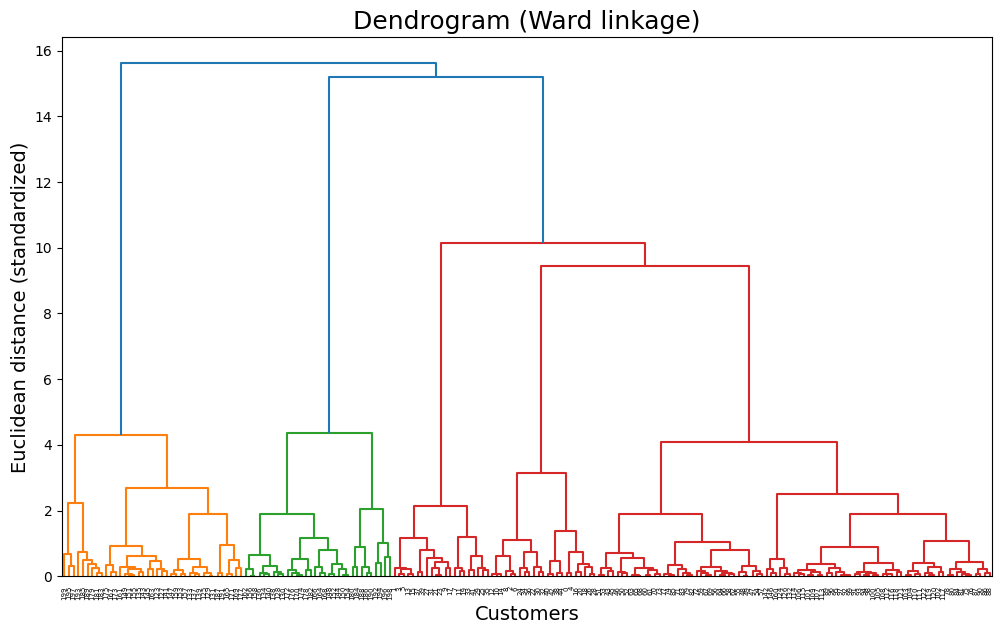

In [17]:
# Plot a dendrogram using method='ward'
plt.figure(figsize=(12, 7))
Z = linkage(X, method='ward')
dendrogram(Z)
plt.title('Dendrogram (Ward linkage)', fontsize=18)
plt.xlabel('Customers', fontsize=14)
plt.ylabel('Euclidean distance (standardized)', fontsize=14)
plt.show()


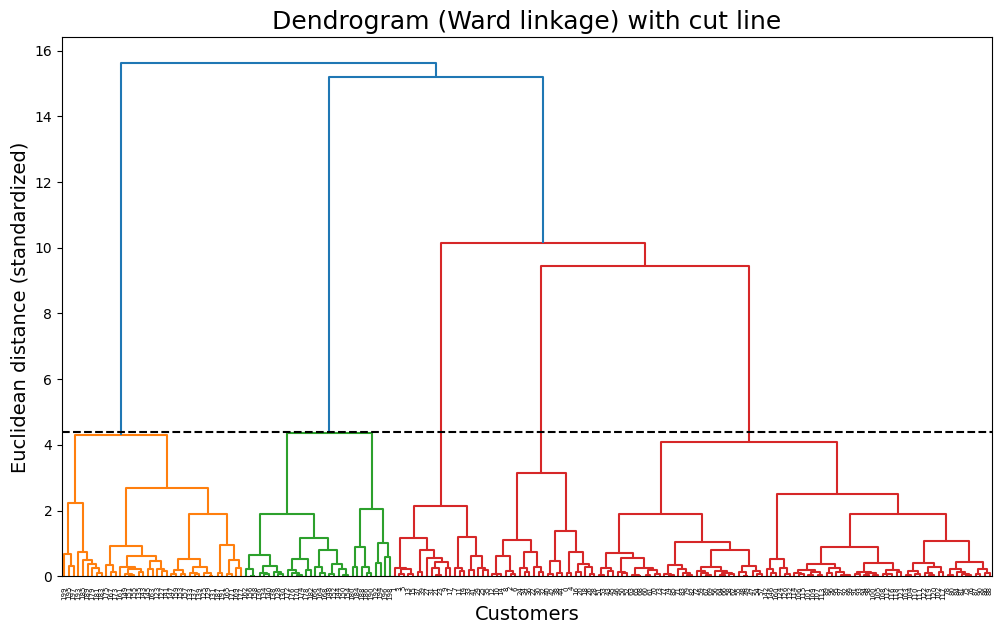

In [18]:
# Plot a dendrogram using method='ward' with a horizontal line crossing 5 vertical lines
# (the cut height below yields ~5 clusters for this dataset)
plt.figure(figsize=(12, 7))
Z = linkage(X, method='ward')
dendrogram(Z)
plt.axhline(y=4.4, c='k', ls='--')
plt.title('Dendrogram (Ward linkage) with cut line', fontsize=18)
plt.xlabel('Customers', fontsize=14)
plt.ylabel('Euclidean distance (standardized)', fontsize=14)
plt.show()


### Hierarchical Clustering

#### Build the model

In [19]:
# Build a model using AgglomerativeClustering(n_clusters = 5, affinity = 'euclidean', linkage = 'ward')
# and save the predictions to a variable called 'y_hc'

# NOTE: In newer scikit-learn versions, 'affinity' is replaced by 'metric'.
try:
    hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
except TypeError:
    hc = AgglomerativeClustering(n_clusters=5, affinity='euclidean', linkage='ward')

y_hc = hc.fit_predict(X)


In [20]:
# Print 'y_hc'
print(y_hc)


[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 2 4 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 2 1 0 1 0 1 2 1 0 1 0 1 0 1 0 1 2 1 0 1 2 1
 0 1 0 1 0 1 0 1 0 1 0 1 2 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]


#### Plot the clusters and label customer types
* _Careful_ - high income but low spenders
* _Standard_ - middle income and middle spenders
* **_Target group_ - middle-to-high income and high spenders (should be targeted by the mall)**
* _Careless_ - low income but high spenders (should be avoided because of possible credit risk)
* _Sensible_ - low income and low spenders

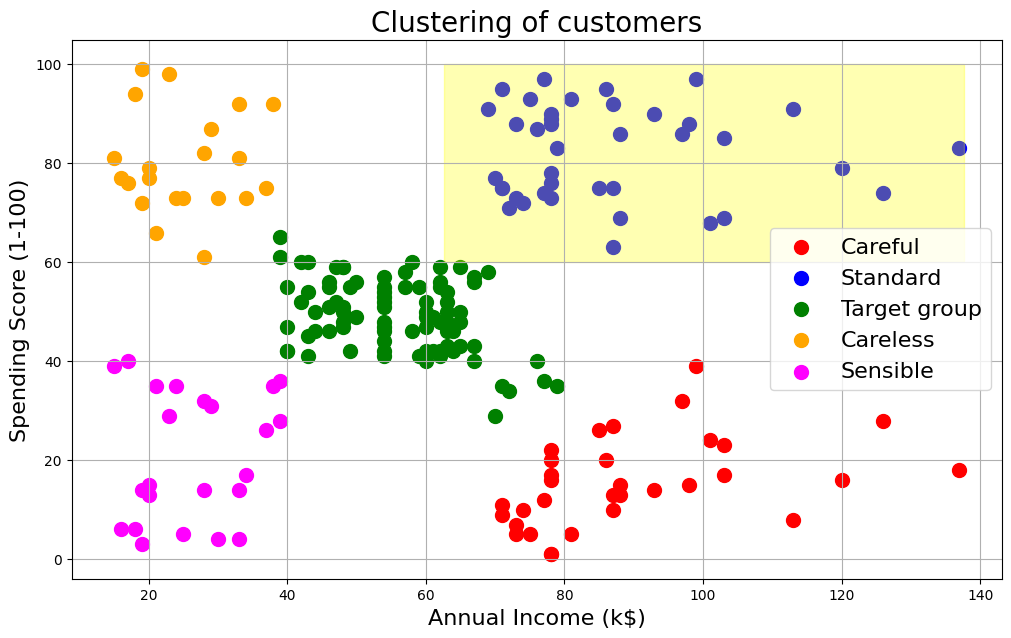

In [21]:
# Plot the cluster using the following code.
plt.figure(figsize=(12,7))
plt.scatter(data[y_hc == 0, 0], data[y_hc == 0, 1], s = 100, c = 'red', label = 'Careful')
plt.scatter(data[y_hc == 1, 0], data[y_hc == 1, 1], s = 100, c = 'blue', label = 'Standard')
plt.scatter(data[y_hc == 2, 0], data[y_hc == 2, 1], s = 100, c = 'green', label = 'Target group')
plt.scatter(data[y_hc == 3, 0], data[y_hc == 3, 1], s = 100, c = 'orange', label = 'Careless')
plt.scatter(data[y_hc == 4, 0], data[y_hc == 4, 1], s = 100, c = 'magenta', label = 'Sensible')
plt.title('Clustering of customers',fontsize=20)
plt.xlabel('Annual Income (k$)',fontsize=16)
plt.ylabel('Spending Score (1-100)',fontsize=16)
plt.legend(fontsize=16)
plt.grid(True)
plt.axhspan(ymin=60,ymax=100,xmin=0.4,xmax=0.96,alpha=0.3,color='yellow')
plt.show()

#### Verify the optimal number of clusters by k-means algorithm

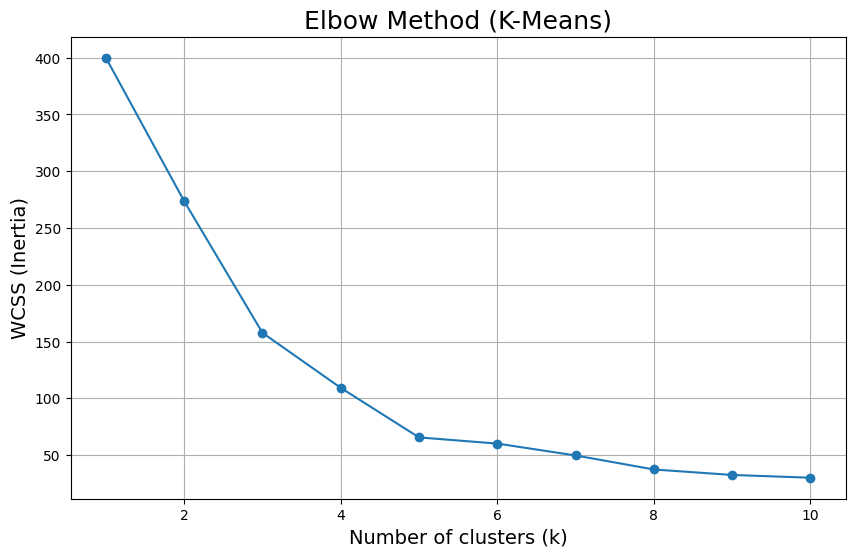

In [22]:
# Using Elbow method find the optimum number of clusters for k-means
wcss = []
K = range(1, 11)

for k in K:
    try:
        km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    except TypeError:
        km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, wcss, marker='o')
plt.title('Elbow Method (K-Means)', fontsize=18)
plt.xlabel('Number of clusters (k)', fontsize=14)
plt.ylabel('WCSS (Inertia)', fontsize=14)
plt.grid(True)
plt.show()

# For this dataset, the elbow typically appears around k=5.
